---
title: Quickstart
description: A quickstart guide for the Shaded lightcones Qiskit addon (qiskit-addon-slc)
---

# Quickstart

This guide demonstrates a minimal working example of the `qiskit-addon-slc` package. We calculate a shaded lightcone to reduce the sampling cost of probabilistic error cancellation (PEC).

PEC mitigates gate noise by sampling from a quasiprobability decomposition of the inverse noise channel. Its sampling cost grows with every error term it must mitigate; however, not every error affects the observable equally. An error outside the observable's causal lightcone cannot influence the measured expectation value at all, and even within the lightcone some errors are more detrimental than others. A shaded lightcone quantifies this by bounding the effect each Pauli error term has on the observable. Truncating the error terms with the smallest effect shrinks the noise model that PEC has to mitigate, reducing sampling cost in exchange for a small, bounded bias.

To see how to build a realistic workflow and run on quantum hardware, check out the [Probabilistic error cancellation with shaded lightcones](https://quantum.cloud.ibm.com/docs/tutorials/pec-with-shaded-lightcones) tutorial on the IBM Quantum Platform.

## 1. Prepare the inputs for SLC

Here we build a 6-qubit Trotterized transverse-field Ising circuit and choose a single-qubit $Z$ observable on the middle qubit.

Observable: IIZIII


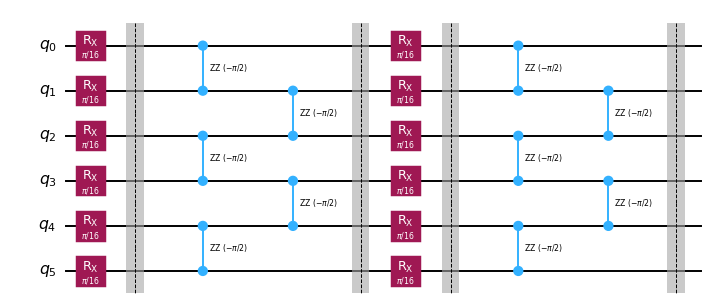

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli


def trotter_ising_circuit(num_qubits, num_steps, rx_angle, rzz_angle):
    """Trotterized transverse-field Ising evolution on a 1D chain."""
    circuit = QuantumCircuit(num_qubits)
    for _ in range(num_steps):
        circuit.rx(rx_angle, range(num_qubits))
        circuit.barrier()
        for start in (0, 1):  # even then odd bonds
            for i in range(start, num_qubits - 1, 2):
                circuit.rzz(rzz_angle, i, i + 1)
        circuit.barrier()
    return circuit


num_qubits = 6
circuit = trotter_ising_circuit(num_qubits, num_steps=2, rx_angle=np.pi / 16, rzz_angle=-np.pi / 2)

# Measure <Z> on the middle qubit
observable = Pauli("I" * num_qubits).compose("Z", [num_qubits // 2])

print(f"Observable: {observable}")
circuit.draw("mpl", fold=-1, scale=0.7)

SLC operates on the noisy two-qubit-gate layers of the circuit. Here we use ``samplomatic`` to group the gates into annotated boxes and attach a noise-injection annotation to each two-qubit layer. `generate_noise_model_paulis` then enumerates the Pauli error terms of every unique noisy layer.

In [2]:
from qiskit_addon_slc.utils import generate_noise_model_paulis
from samplomatic.transpiler import generate_boxing_pass_manager
from samplomatic.utils import find_unique_box_instructions

# Group gates into boxes and annotate each two-qubit layer with a noise-injection point
boxing_pass = generate_boxing_pass_manager(
    inject_noise_targets="all",
    inject_noise_strategy="individual_modification",
    inject_noise_site="after",
    twirling_strategy="active",
    remove_barriers="never",
)
boxed_circuit = boxing_pass.run(circuit)

# Enumerate the 1- and 2-weight Pauli error terms of each unique noisy layer
noise_model_paulis = generate_noise_model_paulis(find_unique_box_instructions(boxed_circuit))

num_terms = sum(len(paulis) for paulis in noise_model_paulis.values())
print(f"Noisy layers: {len(noise_model_paulis)}")
print(f"Pauli error terms across all layers: {num_terms}")

Noisy layers: 2
Pauli error terms across all layers: 102


## 2. Compute the shaded lightcone

The shaded lightcone is assembled by assigning a scale to each Pauli error term in the noise model based on how much effect it has on the observable expectation value. These scales are derived from each error term's forward and backward error bounds (described below), as well as its error rate:

- `compute_forward_bounds` evolves each error term *forward* to the end of the circuit to bound its effect on the observable measured there.
- `compute_backward_bounds` evolves each error term *backward* to the start of the circuit to bound its effect on the initial state.

`merge_bounds` combines the two into a single bound per error term. Merging scales each bound by the term's error rate. These rates typically come from a noise-learning experiment (e.g. `NoiseLearnerV3`); here we use random rates for simplicity.

In [3]:
from qiskit.quantum_info import PauliLindbladMap, QubitSparsePauliList
from qiskit_addon_slc.bounds import (
    compute_backward_bounds,
    compute_forward_bounds,
    merge_bounds,
)

forward_bounds = compute_forward_bounds(boxed_circuit, noise_model_paulis, observable)
backward_bounds = compute_backward_bounds(boxed_circuit, noise_model_paulis)

# Stand-in for rates that would be measured by a noise-learning experiment on hardware
rng = np.random.default_rng(42)
noise_rates = {
    layer_id: PauliLindbladMap.from_components(
        rng.random(len(paulis)) * 5e-3,
        QubitSparsePauliList.from_sparse_list(paulis.to_sparse_list(), paulis.num_qubits),
    )
    for layer_id, paulis in noise_model_paulis.items()
}

merged_bounds = merge_bounds(boxed_circuit, forward_bounds, backward_bounds, noise_rates)

In the shaded lightcone visualization below, each box is shaded by how strongly the errors at that site can affect the observable: bright boxes carry the largest bounds, while boxes that fade to the background contain error terms which have little effect on the calculation -- these errors are natural candidates to drop from the noise model. The values in the visualization below represent sums of the error bounds of all Pauli errors at that site, which is why some of the values grow larger than ``2.0`` -- the bound for any single Pauli error.

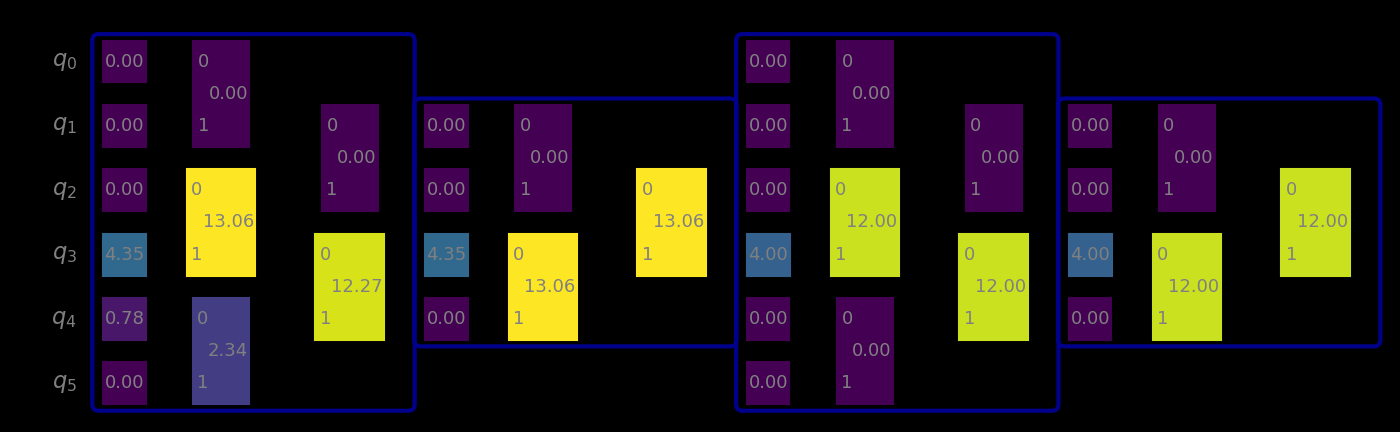

In [4]:
from qiskit_addon_slc.visualization import draw_shaded_lightcone

draw_shaded_lightcone(boxed_circuit, merged_bounds, noise_model_paulis)

## 3. Reduce the sampling cost

`compute_local_scales` turns the shaded lightcone into a concrete PEC configuration. It prioritizes error terms by their bounded effect on the observable and truncates the least impactful ones until the requested `bias_tolerance` is reached. It returns scales for each error term -- `0.0` for terms to ignore during mitigation and `-1.0` for terms which should be mitigated. The function also returns the resulting **sampling cost** overhead ($\gamma^2$) and a bound on the **residual bias** incurred by the truncation.

Setting `bias_tolerance=0.0` mitigates every error term within the causal lightcone of the observable and gives a baseline sampling cost. Allowing a small bias lets SLC drop the low-impact terms and reduce that cost further.

In [5]:
from qiskit_addon_slc.bounds import compute_local_scales

_, full_cost, full_bias = compute_local_scales(
    boxed_circuit, merged_bounds, noise_rates, bias_tolerance=0.0
)
local_scales, reduced_cost, reduced_bias = compute_local_scales(
    boxed_circuit, merged_bounds, noise_rates, bias_tolerance=0.05
)

print(
    f"Full PEC (bias_tolerance=0.0):  sampling cost {full_cost:.3f}, residual bias {full_bias:.3f}"
)
print(
    f"Shaded    (bias_tolerance=0.05): sampling cost {reduced_cost:.3f}, residual bias {reduced_bias:.3f}"
)
print(f"\nSampling-cost reduction: {(1 - reduced_cost / full_cost):.0%} for <= 0.05 bias")

Full PEC (bias_tolerance=0.0):  sampling cost 1.923, residual bias 0.000
Shaded    (bias_tolerance=0.05): sampling cost 1.441, residual bias 0.044

Sampling-cost reduction: 25% for <= 0.05 bias
